## 우리금융 실습 5주차

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, fetch_openml, load_diabetes
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb

## 1. Kernel SVM

In [2]:
# Load German credit data
german = fetch_openml("credit-g", version=1, as_frame=True)
german_df = german['data']
german_y= german.target

# Encode categorical data (convert strings to numbers)
label_encoder = LabelEncoder()
X_encoded = german_df.apply(label_encoder.fit_transform)
y_encoded = label_encoder.fit_transform(german_y)

# Split the data (train/test sets)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature scaling - Scaling is crucial for kernel SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create SVM model with Radial kernel (RBF)
# C = Regularization parameter (Cost)
svm_model = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification_report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7300

Classification_report:
              precision    recall  f1-score   support

           0       0.61      0.28      0.39        60
           1       0.75      0.92      0.83       140

    accuracy                           0.73       200
   macro avg       0.68      0.60      0.61       200
weighted avg       0.71      0.73      0.69       200



In [3]:
# Tuning Hyperparameter
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_encoded, y_encoded)
print("\nBest Hyperparameter:")
print(grid_search.best_params_)
print(f"best_score: {grid_search.best_score_:.4f}")


Best Hyperparameter:
{'C': 1, 'gamma': 0.001}
best_score: 0.7040


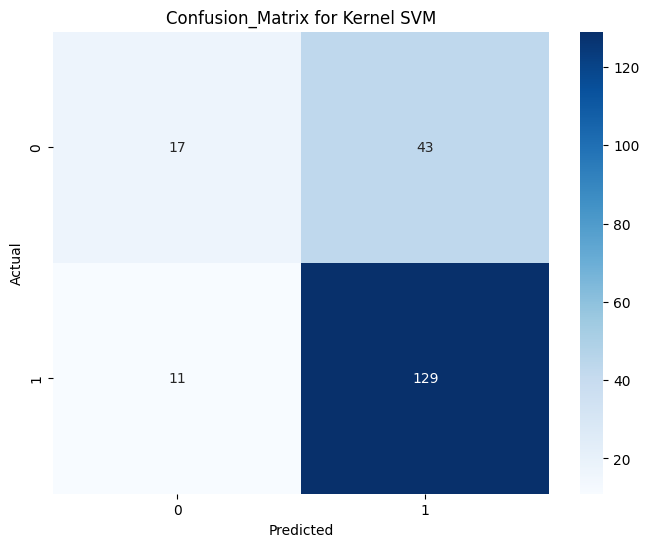

In [4]:
# Confusion_Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion_Matrix for Kernel SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 2. 계층적 군집분석

In [5]:
from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

### Scatter plot about 5 variable

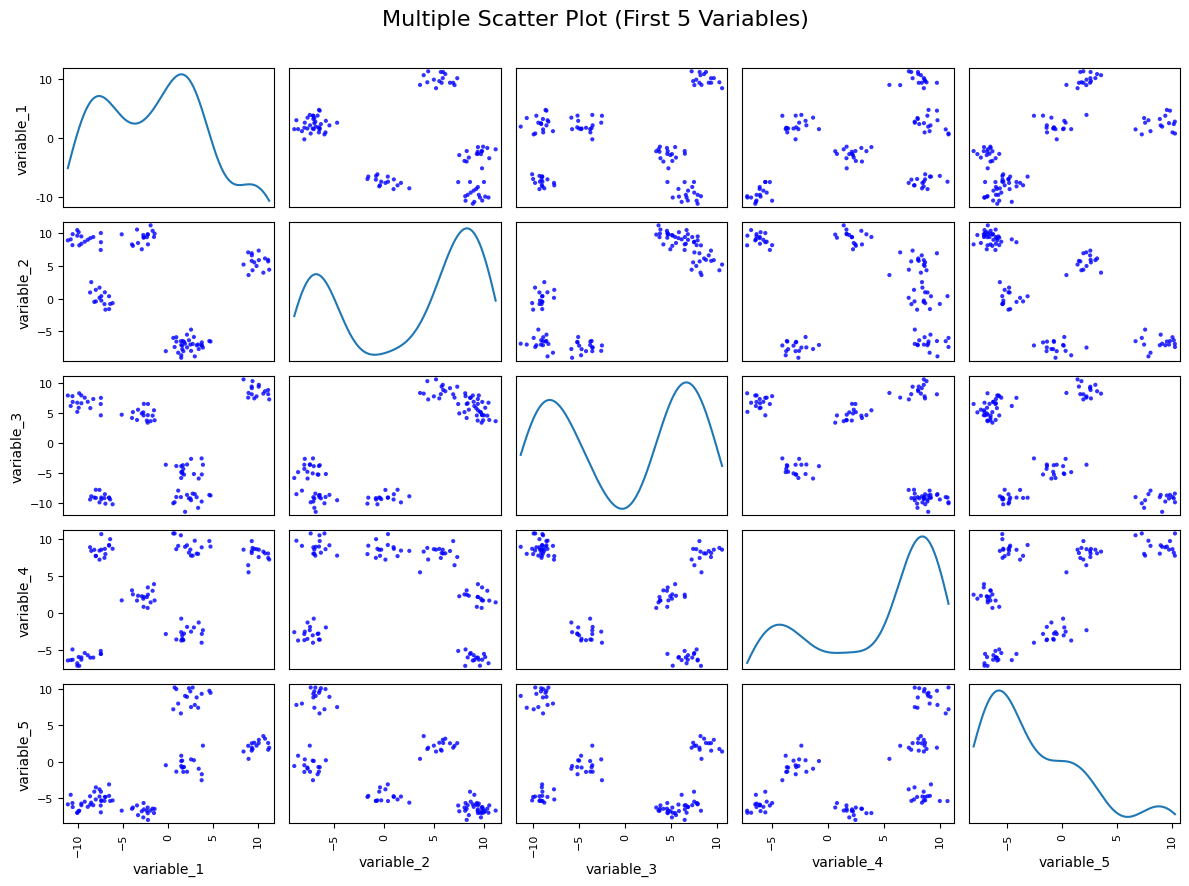

In [6]:
# Setting
n_samples = 100
n_features = 10

# Generate Data
X, y = make_blobs(n_samples=n_samples, n_features=n_features,
                  centers=6, random_state=42)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# scatter_plot with first 5 variables
feature_names = [f'variable_{i+1}' for i in range(n_features)]
df_X = pd.DataFrame(X, columns=feature_names)
selected_columns = df_X.columns[:5]
X_selected_df = df_X[selected_columns]

pd.plotting.scatter_matrix(X_selected_df, alpha=0.8, diagonal='kde', figsize=(12, 9), color='blue')
plt.suptitle('Multiple Scatter Plot (First 5 Variables)', size=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Dendrogram with average linkage according to Distance method

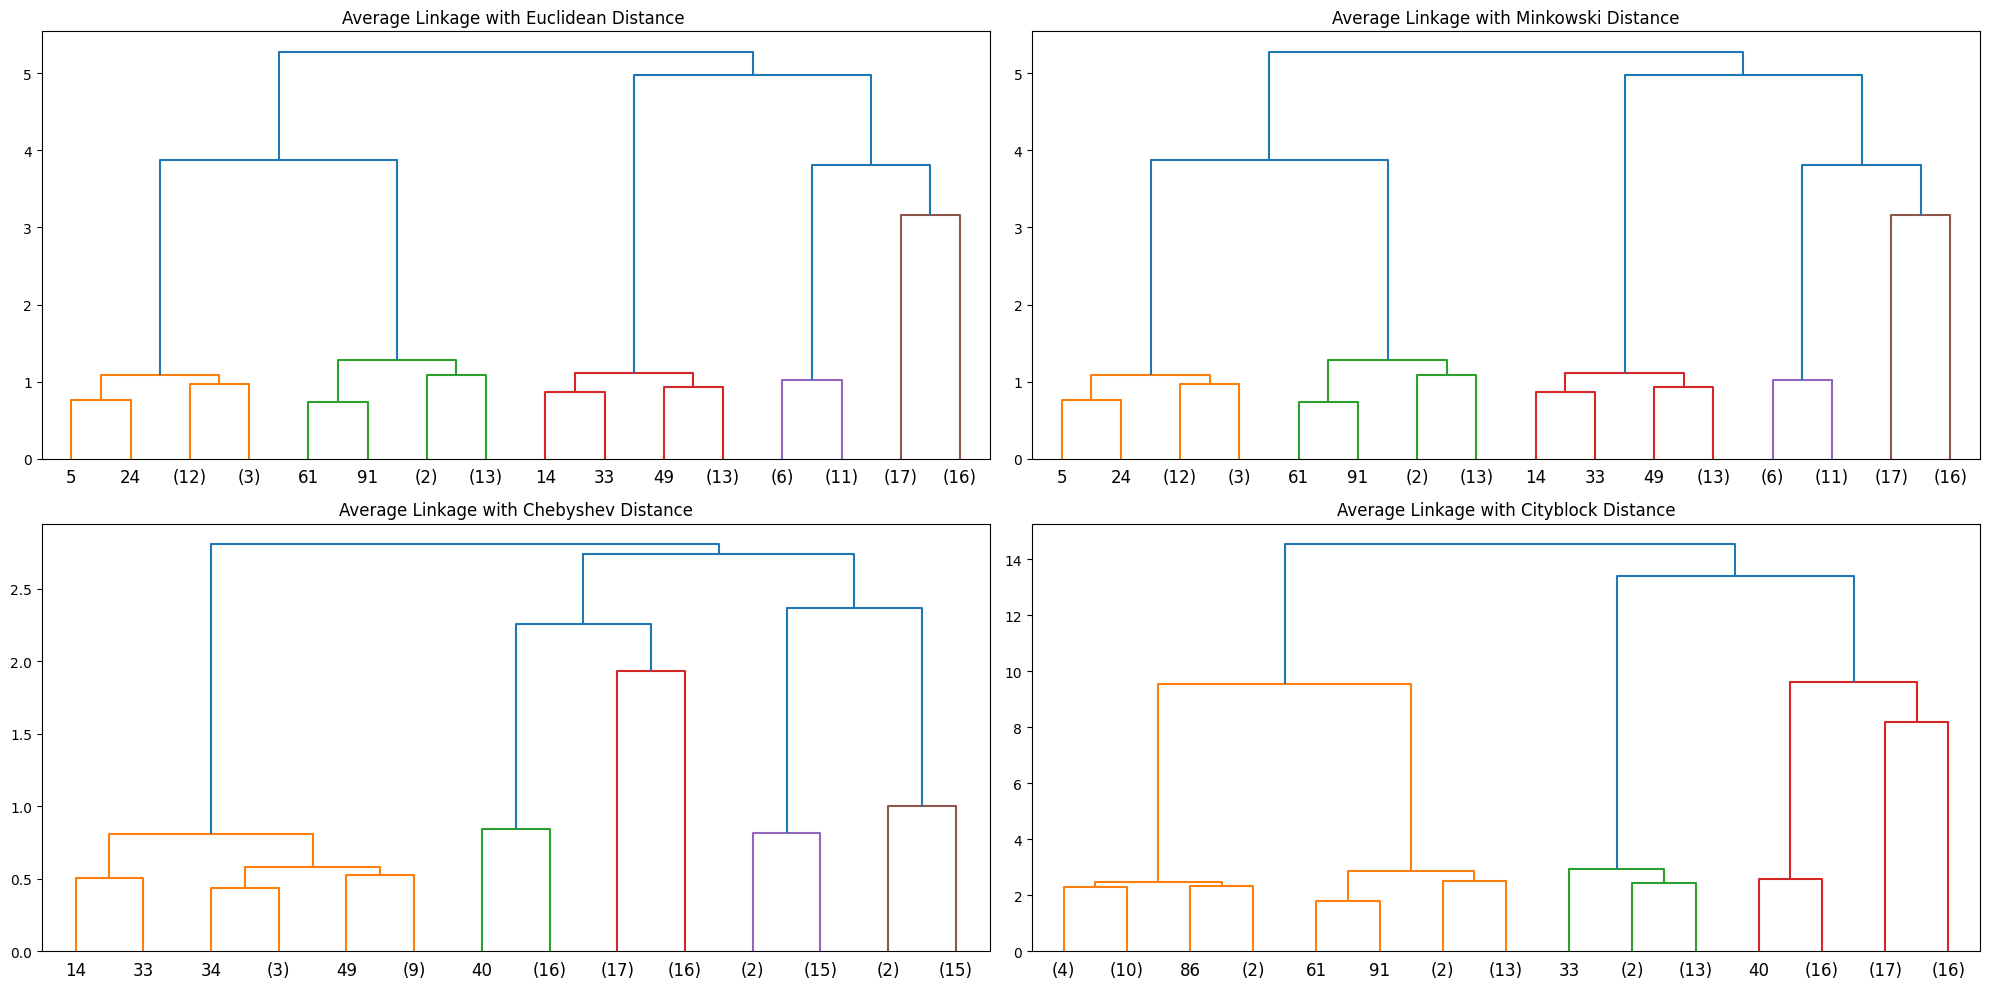

In [7]:
# Dendrogram with average linkage according to Distance method
fig = plt.figure(figsize=(20, 10))

'''metric = euclidean, minkowski, chebyshev(max), cityblock(Manhattan)'''
# metric='euclidean'
ax1 = fig.add_subplot(2, 2, 1)
dend1 = linkage(X_scaled, metric='euclidean', method='average')
dendrogram(dend1, ax=ax1, truncate_mode='level', p=3)
ax1.set_title('Average Linkage with Euclidean Distance ')

# metric='minkowski'
ax2 = fig.add_subplot(2, 2, 2)
dend2 = linkage(X_scaled, metric='minkowski', method='average')
dendrogram(dend2, ax=ax2, truncate_mode='level', p=3)
ax2.set_title('Average Linkage with Minkowski Distance')

# metric='chebyshev'
ax3 = fig.add_subplot(2, 2, 3)
dend3 = linkage(X_scaled, metric='chebyshev', method='average')
dendrogram(dend3, ax=ax3, truncate_mode='level', p=3)
ax3.set_title('Average Linkage with Chebyshev Distance')

# metric='cityblock'
ax4 = fig.add_subplot(2, 2, 4)
dend4 = linkage(X_scaled, metric='cityblock', method='average')
dendrogram(dend4, ax=ax4, truncate_mode='level', p=3)
ax4.set_title('Average Linkage with Cityblock Distance')

plt.tight_layout()
plt.show()

### Dendrogram with euclidean distance according to linkage method

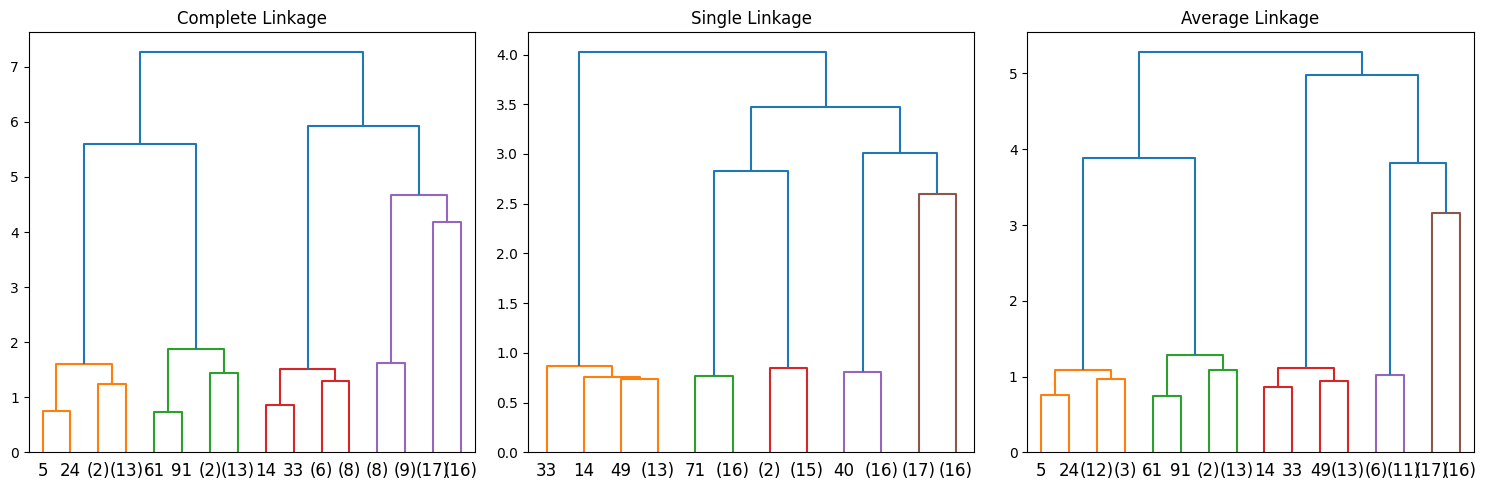

In [8]:
# linkage_methods
linkage_methods = ['complete', 'single', 'average']
plt.figure(figsize=(15, 5))

cluster_assignments = {}

for i, method in enumerate(linkage_methods):
    plt.subplot(1, 3, i+1)
    Z = linkage(X_scaled,metric='euclidean', method=method)
    clusters = fcluster(Z, t=3, criterion='maxclust')  # 3개의 클러스터 생성
    cluster_assignments[method] = clusters

    # 덴드로그램 그리기 (클러스터별 색상 지정)
    dendrogram(Z, truncate_mode='level', p=3,
               color_threshold=np.max(Z[:, 2]) * 0.7)
    plt.title(f'{method.capitalize()} Linkage')

plt.tight_layout()
plt.show()

In [9]:
for method in linkage_methods:
    print(f'\nSummary for {method.capitalize()} linkage:')

    # Create dataframe with cluster assignments
    X_summary = pd.DataFrame(X, columns=[f'Feature {i+1}' for i in range(10)])
    X_summary['Cluster'] = cluster_assignments[method]

    # Calculate cluster sizes and means only
    cluster_sizes = X_summary.groupby('Cluster').size()
    cluster_means = X_summary.groupby('Cluster').mean().round(2)

    # Print simplified results
    for cluster in sorted(cluster_sizes.index):
        print(f"Cluster {cluster}: {cluster_sizes[cluster]} samples")
        print(f"  Key feature means: Feature 1={cluster_means.loc[cluster, 'Feature 1']}, "
              f"Feature 2={cluster_means.loc[cluster, 'Feature 2']}, "
              f"Feature 10={cluster_means.loc[cluster, 'Feature 10']}")
    print("-" * 50)


Summary for Complete linkage:
Cluster 1: 34 samples
  Key feature means: Feature 1=-6.06, Feature 2=9.25, Feature 10=0.08
Cluster 2: 16 samples
  Key feature means: Feature 1=9.87, Feature 2=5.6, Feature 10=-3.29
Cluster 3: 50 samples
  Key feature means: Feature 1=-0.81, Feature 2=-4.76, Feature 10=-5.32
--------------------------------------------------

Summary for Single linkage:
Cluster 1: 16 samples
  Key feature means: Feature 1=9.87, Feature 2=5.6, Feature 10=-3.29
Cluster 2: 34 samples
  Key feature means: Feature 1=-6.06, Feature 2=9.25, Feature 10=0.08
Cluster 3: 50 samples
  Key feature means: Feature 1=-0.81, Feature 2=-4.76, Feature 10=-5.32
--------------------------------------------------

Summary for Average linkage:
Cluster 1: 34 samples
  Key feature means: Feature 1=-6.06, Feature 2=9.25, Feature 10=0.08
Cluster 2: 16 samples
  Key feature means: Feature 1=9.87, Feature 2=5.6, Feature 10=-3.29
Cluster 3: 50 samples
  Key feature means: Feature 1=-0.81, Feature 2=-

### Scatter plot according to linkage method

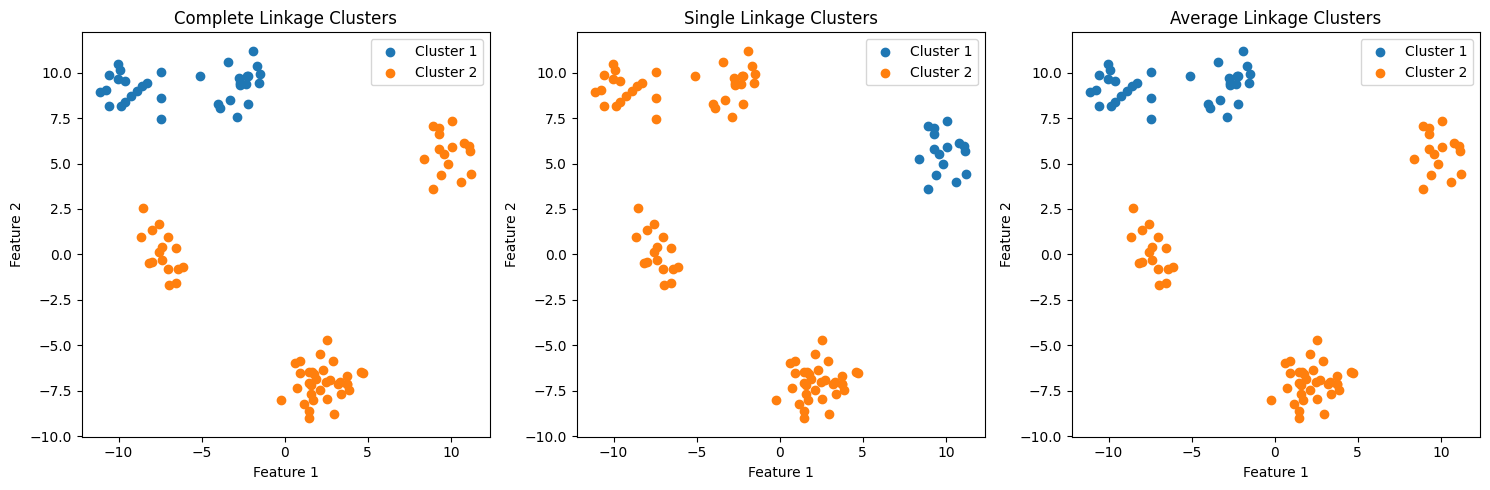

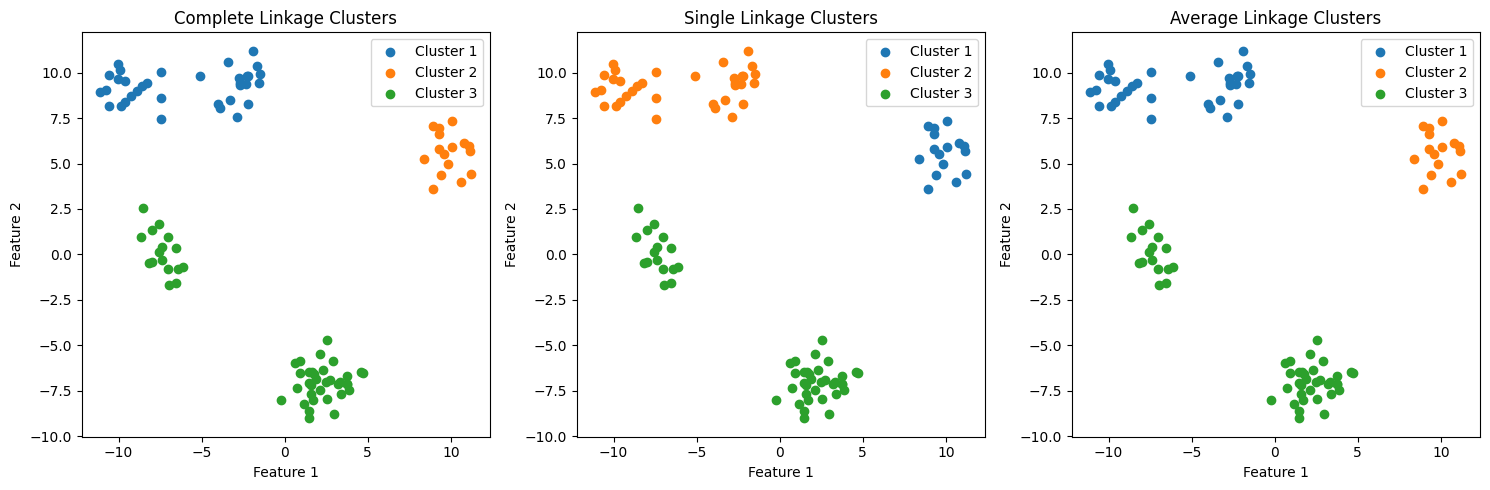

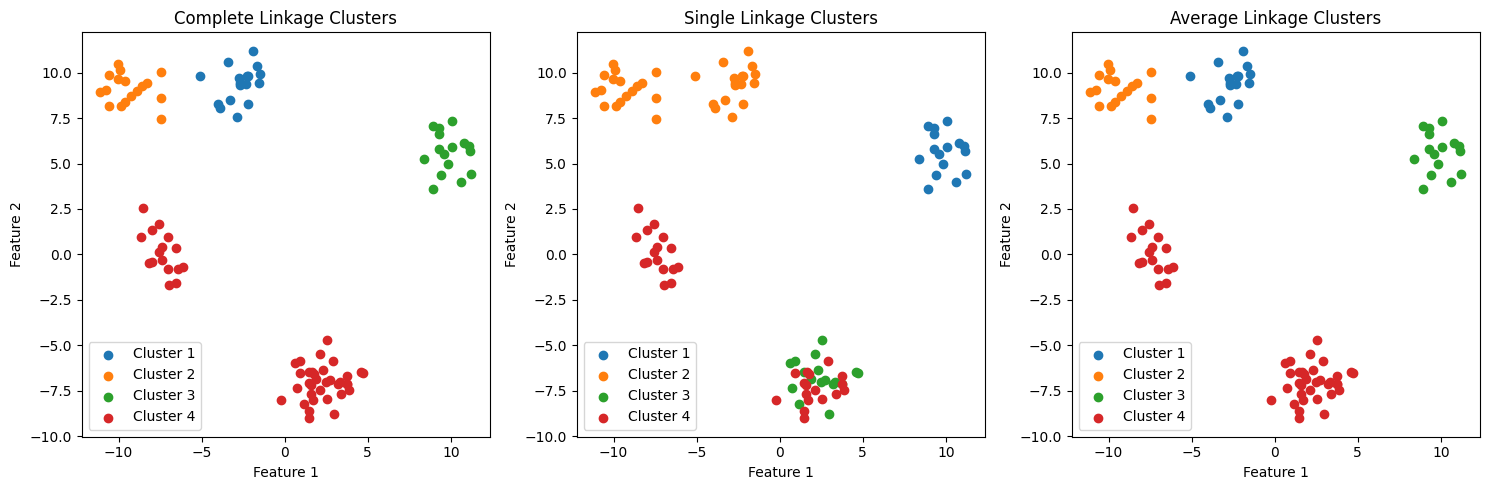

In [10]:
# linkage_methods
linkage_methods = ['complete', 'single', 'average']

for k in [2,3,4] :

    cluster_assignments = {}
    # 각 method별 산점도 그리기
    plt.figure(figsize=(15, 5))
    for i, method in enumerate(linkage_methods):
        Z = linkage(X_scaled,metric='euclidean', method=method)
        clusters = fcluster(Z, t=k, criterion='maxclust')  # 3개의 클러스터 생성
        cluster_assignments[method] = clusters
        plt.subplot(1, 3, i+1)
        clusters = cluster_assignments[method]
        unique_clusters = np.unique(clusters)
        for cluster_id in unique_clusters:
            subset = X[clusters == cluster_id]
            plt.scatter(subset[:, 0], subset[:, 1], label=f'Cluster {cluster_id}')
        plt.title(f'{method.capitalize()} Linkage Clusters')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()

    plt.tight_layout()
    plt.show()

## 3. K-Means Clustering

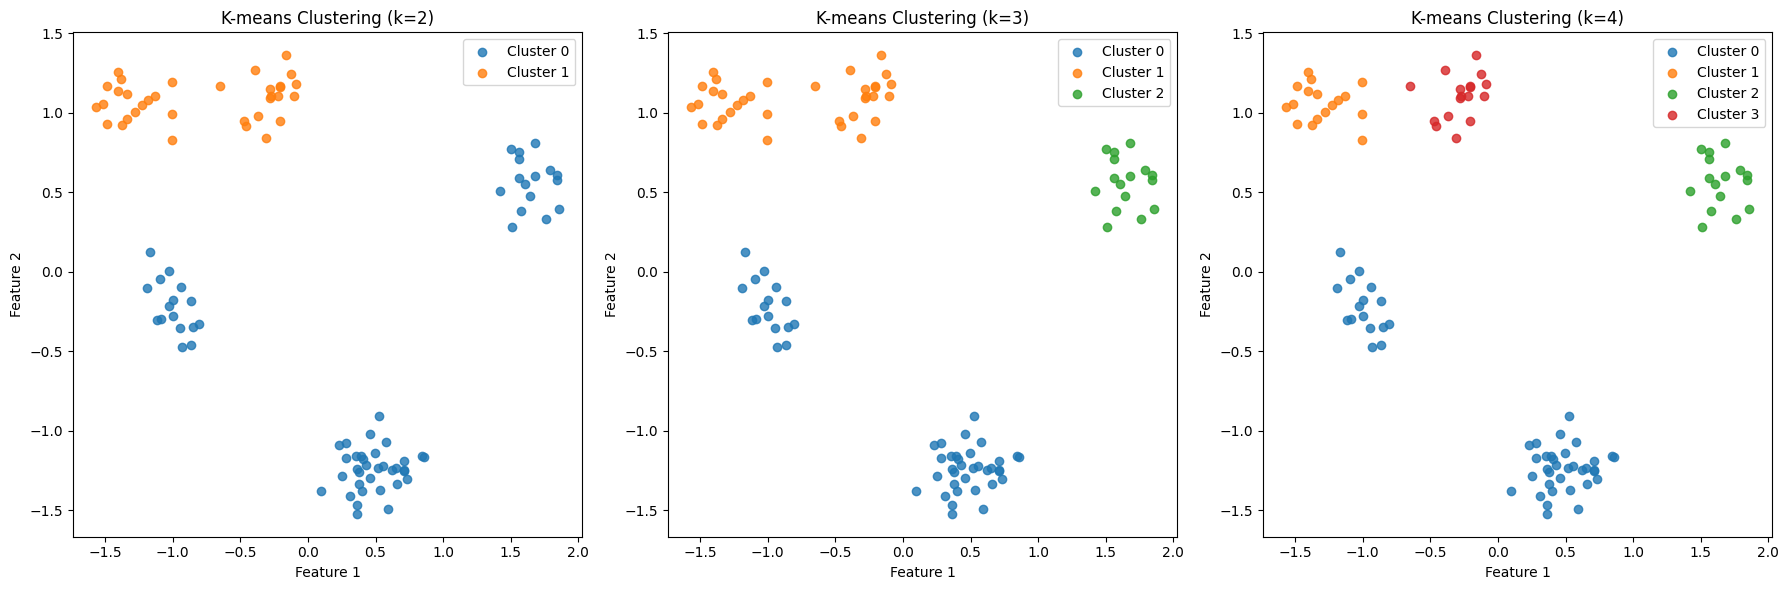

In [11]:
# K-means clustering analysis
kmeans_assignments = {}

# K-means with subplots
plt.figure(figsize=(18, 6))

for i, k in enumerate([2, 3, 4]):
    # Create subplot
    plt.subplot(1, 3, i+1)

    # Fit K-means
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    kmeans_assignments[k] = kmeans.labels_

    # Plot clusters
    unique_clusters = np.unique(kmeans_assignments[k])
    for cluster_id in unique_clusters:
        subset = X_scaled[kmeans_assignments[k] == cluster_id]
        plt.scatter(subset[:, 0], subset[:, 1], label=f'Cluster {cluster_id}', alpha=0.8)

    plt.title(f'K-means Clustering (k={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()

plt.tight_layout()
plt.show()

In [12]:
for method in linkage_methods:
    print(f'\nSummary for {method.capitalize()} linkage:')

    # Create dataframe with cluster assignments
    X_summary = pd.DataFrame(X, columns=[f'Feature {i+1}' for i in range(10)])
    X_summary['Cluster'] = cluster_assignments[method]

    # Calculate cluster sizes and means only
    cluster_sizes = X_summary.groupby('Cluster').size()
    cluster_means = X_summary.groupby('Cluster').mean().round(2)

    # Print simplified results
    for cluster in sorted(cluster_sizes.index):
        print(f"Cluster {cluster}: {cluster_sizes[cluster]} samples")
        print(f"  Key feature means: Feature 1={cluster_means.loc[cluster, 'Feature 1']}, "
              f"Feature 2={cluster_means.loc[cluster, 'Feature 2']}, "
              f"Feature 10={cluster_means.loc[cluster, 'Feature 10']}")
    print("-" * 50)


Summary for Complete linkage:
Cluster 1: 17 samples
  Key feature means: Feature 1=-2.73, Feature 2=9.39, Feature 10=4.26
Cluster 2: 17 samples
  Key feature means: Feature 1=-9.38, Feature 2=9.11, Feature 10=-4.1
Cluster 3: 16 samples
  Key feature means: Feature 1=9.87, Feature 2=5.6, Feature 10=-3.29
Cluster 4: 50 samples
  Key feature means: Feature 1=-0.81, Feature 2=-4.76, Feature 10=-5.32
--------------------------------------------------

Summary for Single linkage:
Cluster 1: 16 samples
  Key feature means: Feature 1=9.87, Feature 2=5.6, Feature 10=-3.29
Cluster 2: 34 samples
  Key feature means: Feature 1=-6.06, Feature 2=9.25, Feature 10=0.08
Cluster 3: 17 samples
  Key feature means: Feature 1=2.45, Feature 2=-6.72, Feature 10=-1.17
Cluster 4: 33 samples
  Key feature means: Feature 1=-2.49, Feature 2=-3.75, Feature 10=-7.46
--------------------------------------------------

Summary for Average linkage:
Cluster 1: 17 samples
  Key feature means: Feature 1=-2.73, Feature 2

In [13]:
# Summary
for k in [2, 3, 4]:
    print(f'\nSummary for K-means Clustering (k={k}):')

    kmeans_summary = pd.DataFrame(X_scaled, columns=[f'Feature {i+1}' for i in range(X_scaled.shape[1])])
    kmeans_summary['Cluster'] = kmeans_assignments[k]

    # Calculate cluster sizes and means only
    cluster_sizes = kmeans_summary.groupby('Cluster').size()
    cluster_means = kmeans_summary.groupby('Cluster').mean().round(2)

    # Print simplified results
    for cluster in sorted(cluster_sizes.index):
        print(f"Cluster {cluster}: {cluster_sizes[cluster]} samples")
        print(f"  Key feature means: Feature 1={cluster_means.loc[cluster, 'Feature 1']}, "
              f"Feature 2={cluster_means.loc[cluster, 'Feature 2']}, "
              f"Feature 10={cluster_means.loc[cluster, 'Feature 10']}")
    print("-" * 50)


Summary for K-means Clustering (k=2):
Cluster 0: 66 samples
  Key feature means: Feature 1=0.41, Feature 2=-0.56, Feature 10=-0.4
Cluster 1: 34 samples
  Key feature means: Feature 1=-0.79, Feature 2=1.08, Feature 10=0.77
--------------------------------------------------

Summary for K-means Clustering (k=3):
Cluster 0: 50 samples
  Key feature means: Feature 1=0.01, Feature 2=-0.92, Feature 10=-0.51
Cluster 1: 34 samples
  Key feature means: Feature 1=-0.79, Feature 2=1.08, Feature 10=0.77
Cluster 2: 16 samples
  Key feature means: Feature 1=1.65, Feature 2=0.56, Feature 10=-0.03
--------------------------------------------------

Summary for K-means Clustering (k=4):
Cluster 0: 50 samples
  Key feature means: Feature 1=0.01, Feature 2=-0.92, Feature 10=-0.51
Cluster 1: 17 samples
  Key feature means: Feature 1=-1.3, Feature 2=1.06, Feature 10=-0.22
Cluster 2: 16 samples
  Key feature means: Feature 1=1.65, Feature 2=0.56, Feature 10=-0.03
Cluster 3: 17 samples
  Key feature means: 

### WSS : within-cluster sum of squares

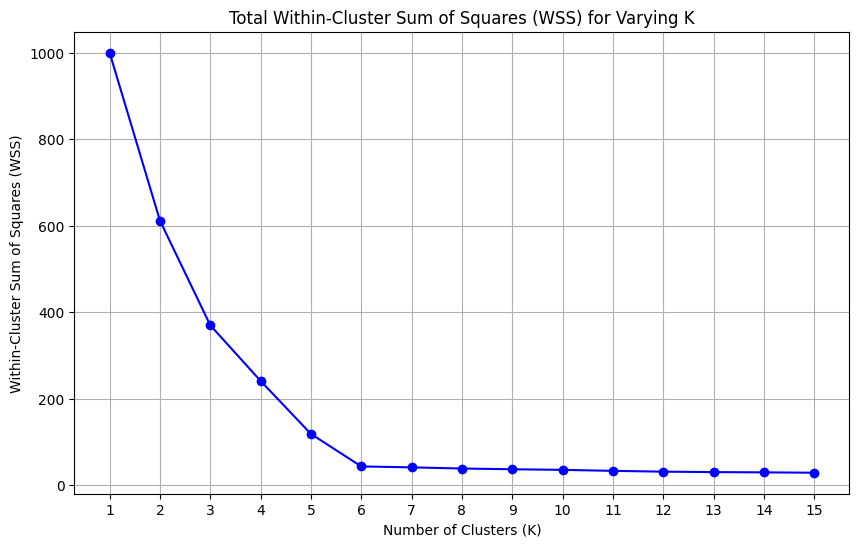

In [14]:
# WSS
wss = []

# from K=1 to K=15
for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), wss, marker='o', linestyle='-', color='b')
plt.title('Total Within-Cluster Sum of Squares (WSS) for Varying K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.xticks(range(1, 16))
plt.grid(True)
plt.show()

### Clustering for Bad Data

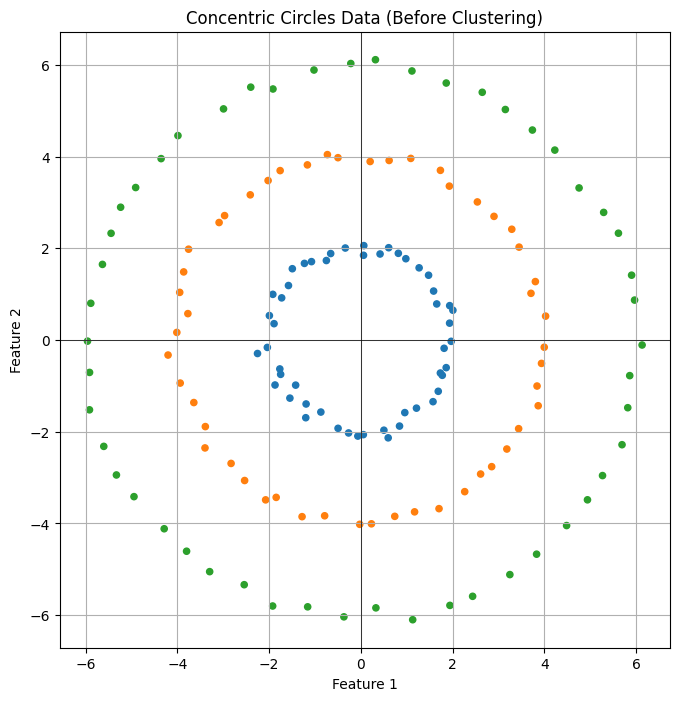

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Number of circles
num_circles = 3
# Points per circle
points_per_circle = 50
# Noise scale
noise_scale = 0.1

X = []
colors = []

for i in range(num_circles):
    # Set radius for each circle (gradually increasing)
    radius = (i + 1) * 2
    # Generate angles from 0 to 2*pi evenly
    theta = np.linspace(0, 2 * np.pi, points_per_circle, endpoint=False)
    # Calculate x, y coordinates (with some noise)
    x = radius * np.cos(theta) + np.random.normal(scale=noise_scale, size=points_per_circle)
    y = radius * np.sin(theta) + np.random.normal(scale=noise_scale, size=points_per_circle)
    X.extend(np.column_stack((x, y)))
    # Assign color for each circle (for visualization)
    colors.extend([f'C{i}'] * points_per_circle)

X = np.array(X)
colors = np.array(colors)

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plot "problematic data" scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=colors, s=20)
plt.title('Concentric Circles Data (Before Clustering)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # To prevent circles from appearing as ellipses
plt.show()

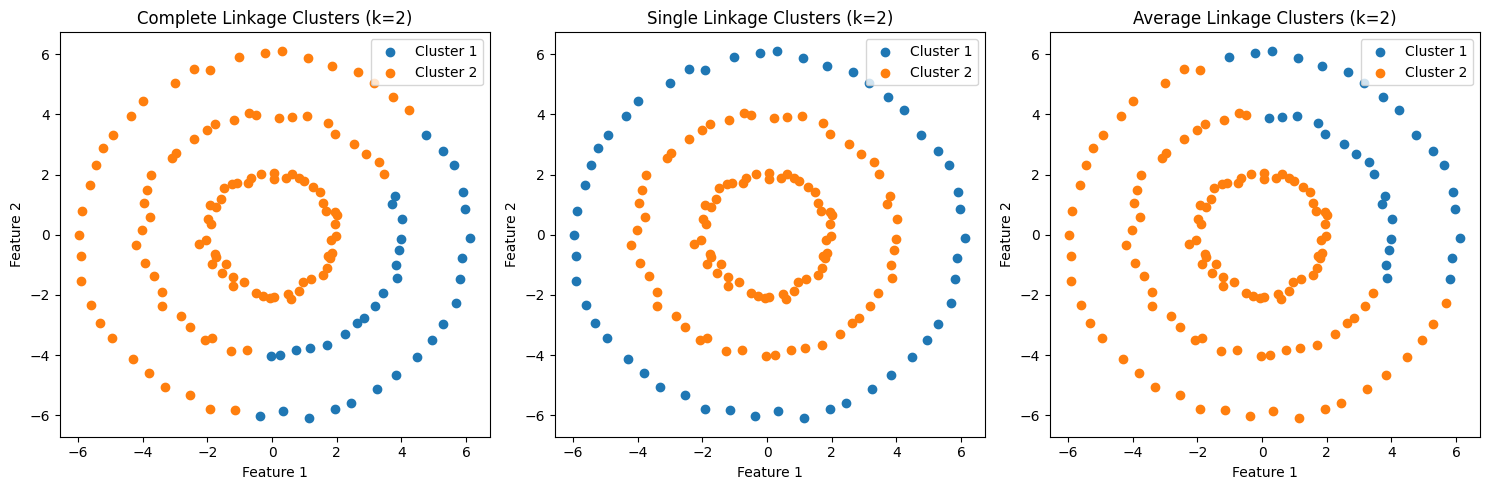

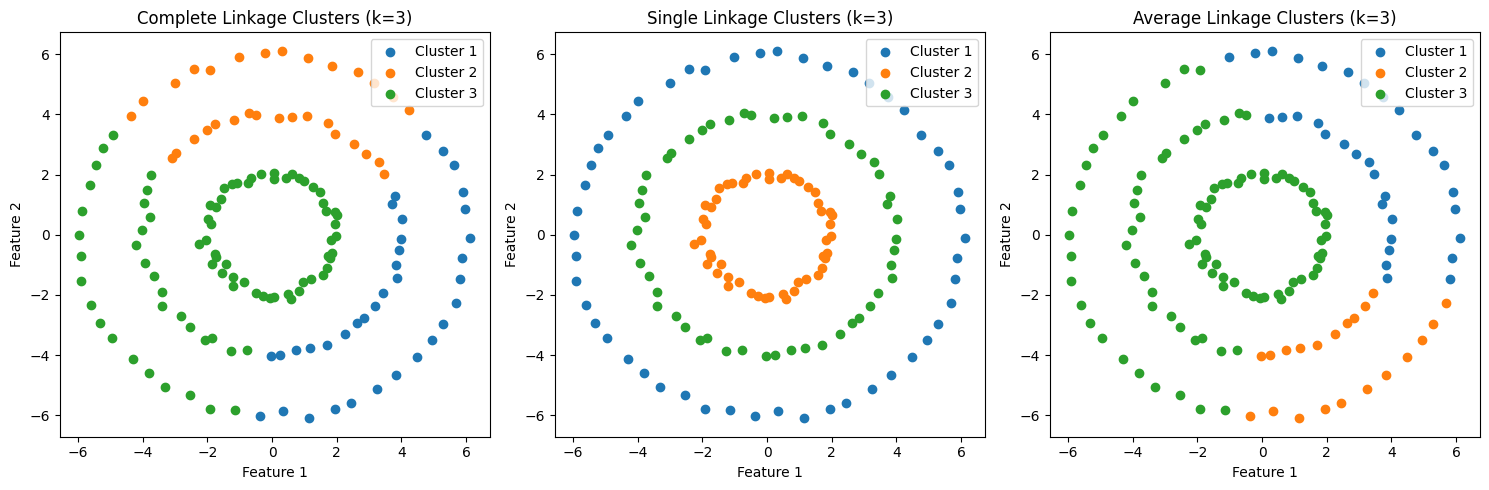

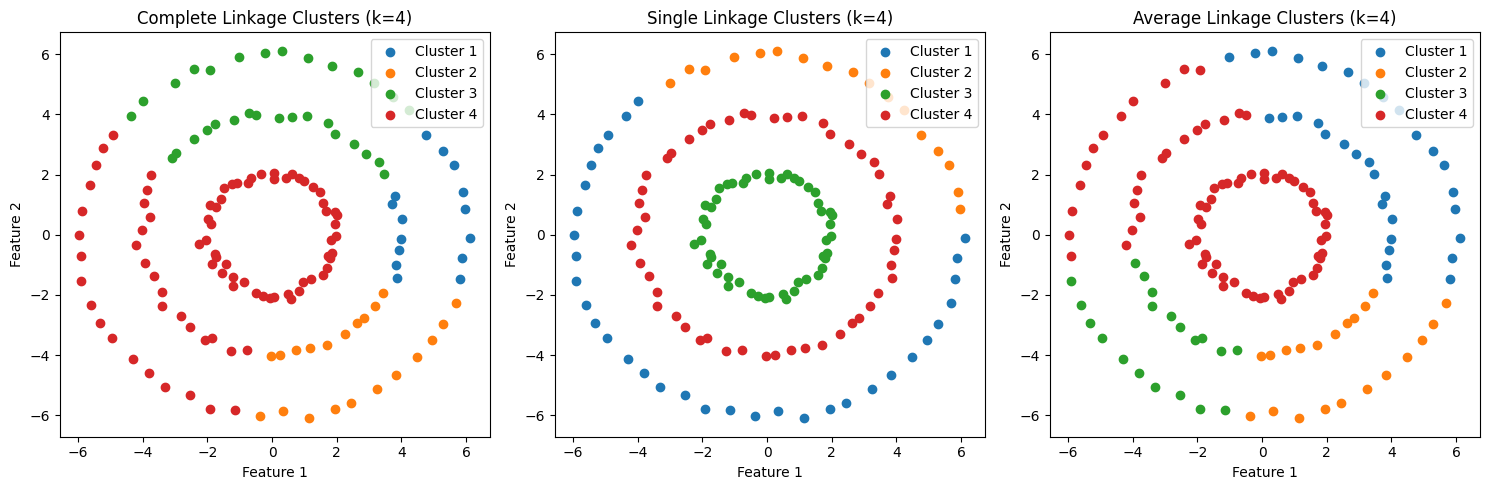

In [16]:
# Hierarchical clustering analysis
linkage_methods = ['complete', 'single', 'average']

for k in [2, 3, 4]:  # Changing number of clusters K
    cluster_assignments = {}
    plt.figure(figsize=(15, 5))

    for i, method in enumerate(linkage_methods):
        Z = linkage(X_scaled, metric='euclidean', method=method)
        clusters = fcluster(Z, t=k, criterion='maxclust')
        cluster_assignments[method] = clusters

        plt.subplot(1, 3, i+1)
        unique_clusters = np.unique(clusters)
        for cluster_id in unique_clusters:
            subset = X[clusters == cluster_id]
            plt.scatter(subset[:, 0], subset[:, 1], label=f'Cluster {cluster_id}')
        plt.title(f'{method.capitalize()} Linkage Clusters (k={k})')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()

    plt.tight_layout()
    plt.show()

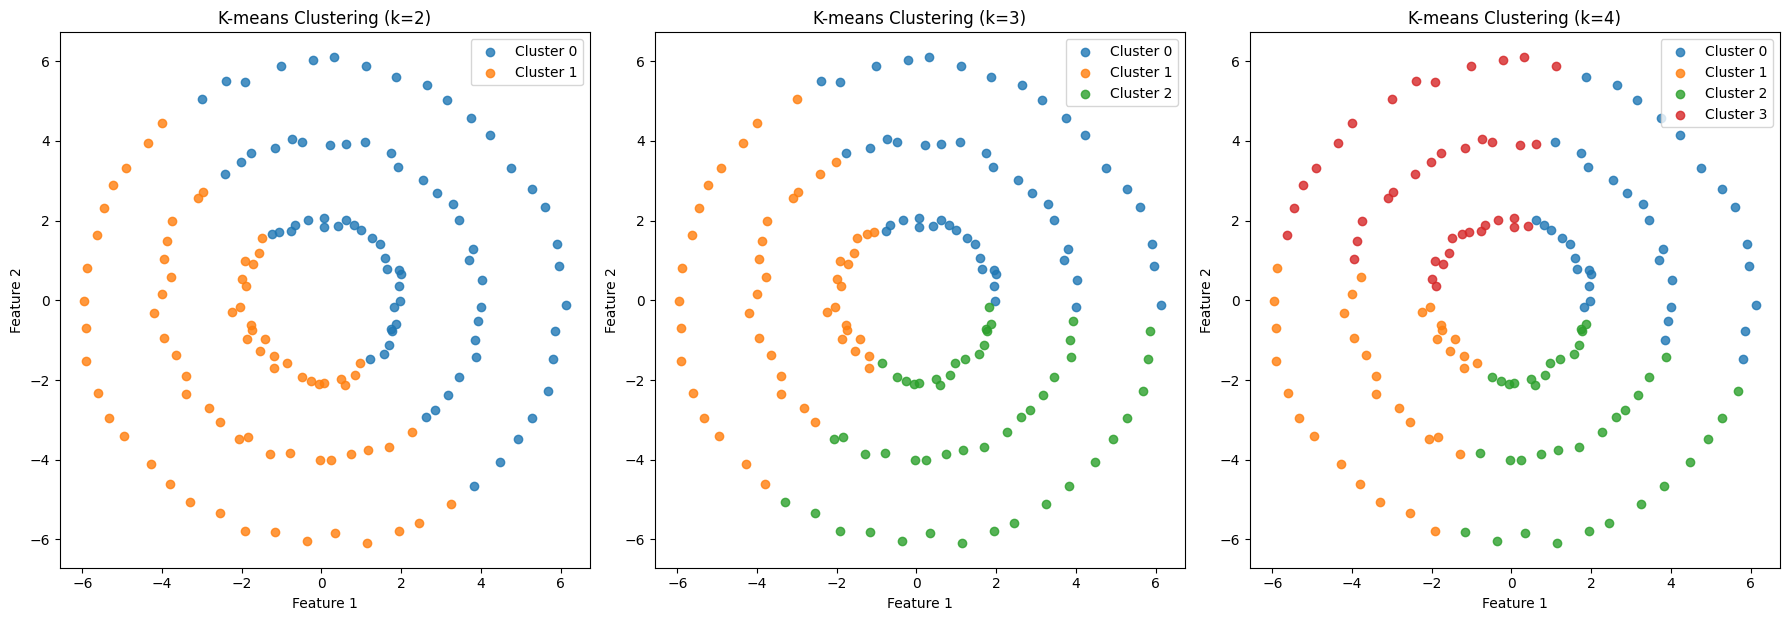

In [17]:
# K-means clustering analysis
kmeans_assignments = {}

# Create one figure with 3 subplots
plt.figure(figsize=(18, 6))

for i, k in enumerate([2, 3, 4]):  # Changing number of clusters K
    # Create subplot for each k value
    plt.subplot(1, 3, i+1)

    # Fit K-means
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    kmeans_assignments[k] = kmeans.labels_

    # Get unique clusters
    unique_clusters = np.unique(kmeans_assignments[k])

    # Draw scatter plot for each cluster
    for cluster_id in unique_clusters:
        subset = X[kmeans_assignments[k] == cluster_id]
        plt.scatter(subset[:, 0], subset[:, 1], label=f'Cluster {cluster_id}', alpha=0.8)

    plt.title(f'K-means Clustering (k={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')  # Maintain aspect ratio

plt.tight_layout()
plt.show()

### 직접해보기

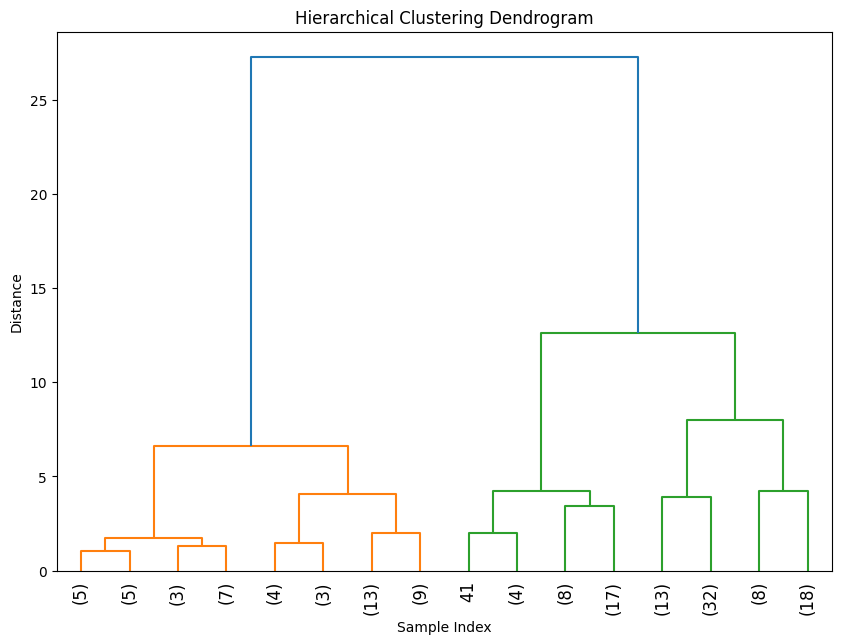

Data with cluster labels:
   sepal_length  sepal_width  petal_length  petal_width  Cluster
0           5.1          3.5           1.4          0.2        1
1           4.9          3.0           1.4          0.2        1
2           4.7          3.2           1.3          0.2        1
3           4.6          3.1           1.5          0.2        1
4           5.0          3.6           1.4          0.2        1


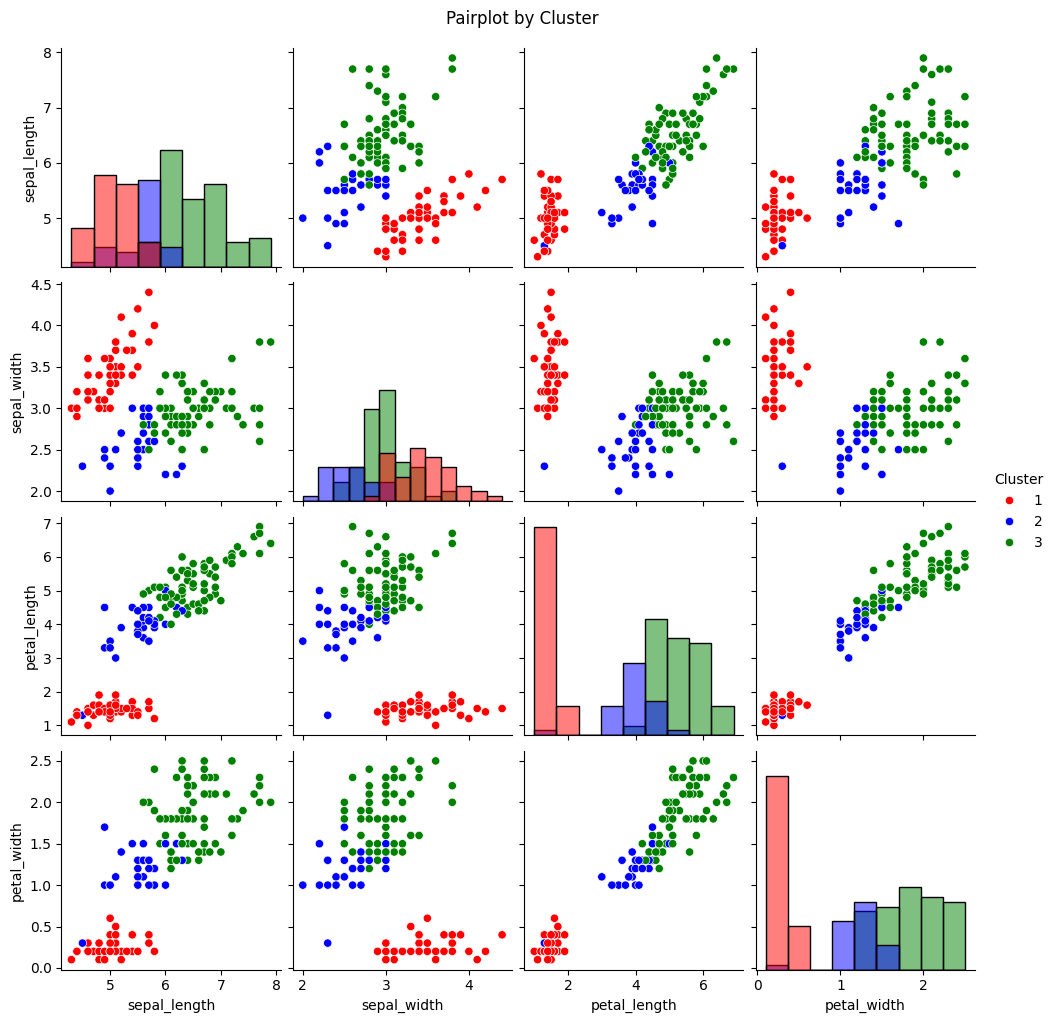

In [18]:
# 1. Load the dataset (using iris dataset as an example)
iris_data = sns.load_dataset("iris")

# 2. Select numeric variables only (excluding categorical variables)
iris_numeric = iris_data.select_dtypes(include=["float64", "int64"])

# 3. Standardize the data to remove scale differences between variables
scaler = StandardScaler()
scaled_data = scaler.fit_transform(iris_numeric)

# 4. Perform hierarchical clustering using the Ward method
Z = linkage(scaled_data, method="ward")

# 5. Visualize the dendrogram to inspect the cluster structure
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=iris_numeric.index, truncate_mode='level', p=3, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

# 6. Assign cluster labels; here, the number of clusters is set to 3
clusters = fcluster(Z, t=3, criterion="maxclust")
iris_numeric["Cluster"] = clusters

print("Data with cluster labels:")
print(iris_numeric.head())

# 7. Visualize the clustering results using a pairplot with custom colors (bold red, blue, green)
custom_palette = {1: "red", 2: "blue", 3: "green"}
sns.pairplot(iris_numeric, hue="Cluster", diag_kind="hist", palette=custom_palette)
plt.suptitle("Pairplot by Cluster", y=1.02)
plt.show()


## 4. 차원축소
### PCA

In [19]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.manifold import TSNE


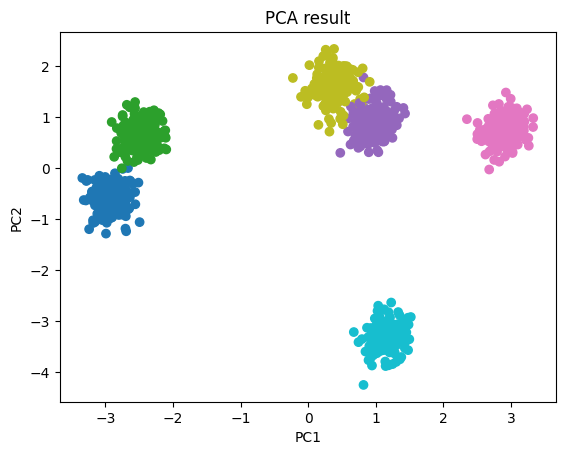

In [20]:

# 데이터 준비
X, y = make_blobs(n_samples=1000, n_features=10, centers=6, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

# PCA 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 시각화
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA result')
plt.show()


### MDS

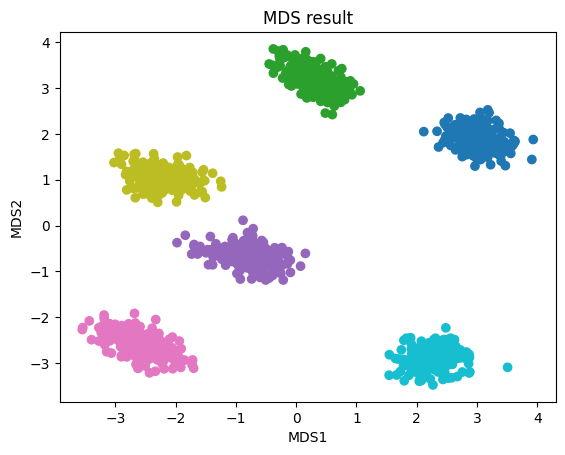

In [21]:
# MDS 적용
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

# 시각화
plt.scatter(X_mds[:,0], X_mds[:,1], c=y, cmap='tab10')
plt.xlabel('MDS1'); plt.ylabel('MDS2'); plt.title('MDS result')
plt.show()


### T-SNE

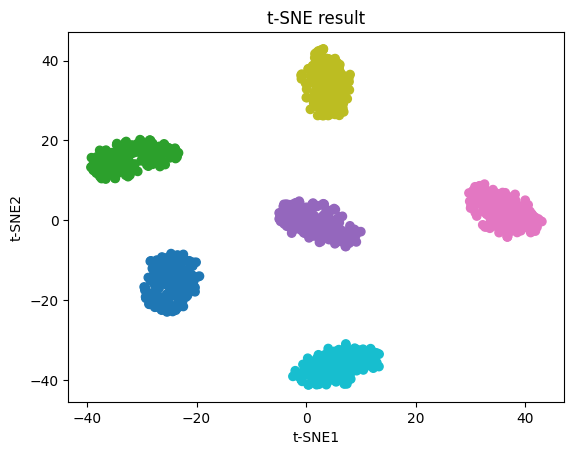

In [22]:
# t-SNE 적용
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 시각화
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='tab10')
plt.xlabel('t-SNE1'); plt.ylabel('t-SNE2'); plt.title('t-SNE result')
plt.show()


### 직접 해보기

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score


In [24]:
# 1. 데이터 로드 & 전처리
data = fetch_openml(name="credit-g", version=1, as_frame=True)
X_raw = data['data']
y = data['target'].map({'bad': 0, 'good': 1}).astype(int)
X = pd.get_dummies(X_raw, drop_first=True)
X_scaled = StandardScaler().fit_transform(X)

# 2. PCA → 2차원 축소 + Logistic
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)
log_pca = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_p, y_train_p)
y_pred_pca = log_pca.predict(X_test_p)

# 3. MDS → 2차원 축소 + Logistic
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mds, y, test_size=0.3, random_state=42, stratify=y
)
log_mds = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_m, y_train_m)
y_pred_mds = log_mds.predict(X_test_m)

# 4. t-SNE → 2차원 축소 + Logistic
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tsne, y, test_size=0.3, random_state=42, stratify=y
)
log_tsne = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_t, y_train_t)
y_pred_tsne = log_tsne.predict(X_test_t)

# 5. 원본 데이터로 Logistic & SVM
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
log = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train_s)
svm = SVC(kernel='rbf', random_state=42).fit(X_train_s, y_train_s)
y_pred_log = log.predict(X_test_s)
y_pred_svm = svm.predict(X_test_s)

# 6. 성능 비교 테이블
results = pd.DataFrame({
    'accuracy': [
        accuracy_score(y_test_p, y_pred_pca),
        accuracy_score(y_test_m, y_pred_mds),
        accuracy_score(y_test_t, y_pred_tsne),
        accuracy_score(y_test_s, y_pred_log),
        accuracy_score(y_test_s, y_pred_svm),
    ],
    'recall': [
        recall_score(y_test_p, y_pred_pca),
        recall_score(y_test_m, y_pred_mds),
        recall_score(y_test_t, y_pred_tsne),
        recall_score(y_test_s, y_pred_log),
        recall_score(y_test_s, y_pred_svm),
    ],
    'precision': [
        precision_score(y_test_p, y_pred_pca),
        precision_score(y_test_m, y_pred_mds),
        precision_score(y_test_t, y_pred_tsne),
        precision_score(y_test_s, y_pred_log),
        precision_score(y_test_s, y_pred_svm),
    ]
}, index=[
    'Logistic (PCA)',
    'Logistic (MDS)',
    'Logistic (t-SNE)',
    'Logistic (원본 데이터)',
    'SVM (원본 데이터)'
])
print(results)


                   accuracy    recall  precision
Logistic (PCA)     0.730000  0.928571   0.747126
Logistic (MDS)     0.700000  1.000000   0.700000
Logistic (t-SNE)   0.696667  0.961905   0.708772
Logistic (원본 데이터)  0.736667  0.842857   0.793722
SVM (원본 데이터)       0.740000  0.914286   0.761905


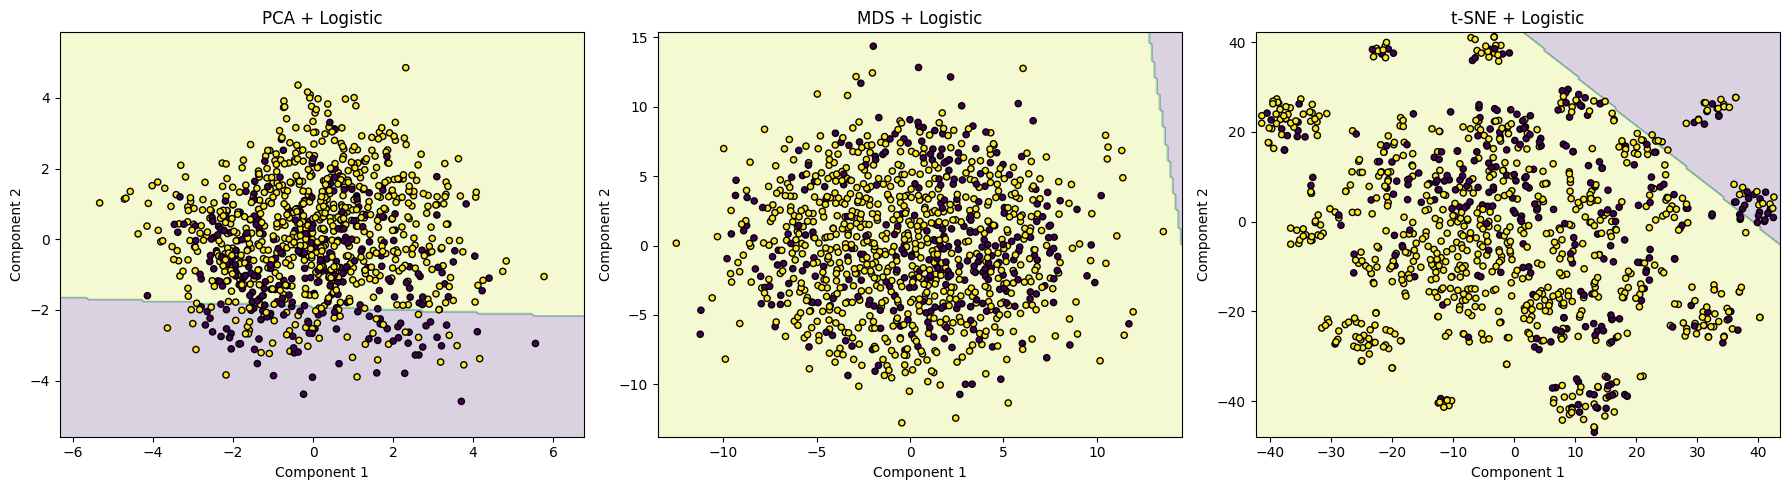

In [25]:
# 차원축소 함수 정의
def reduce_and_classify(reducer, X_scaled, y, title):
    X_red = reducer.fit_transform(X_scaled)
    X_train, X_test, y_train, y_test = train_test_split(
        X_red, y, test_size=0.3, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)

    # 결정 경계 생성
    xmin, xmax = X_red[:,0].min()-1, X_red[:,0].max()+1
    ymin, ymax = X_red[:,1].min()-1, X_red[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200),
                         np.linspace(ymin, ymax, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # 시각화
    plt.contourf(xx, yy, Z, alpha=0.2)
    plt.scatter(X_red[:,0], X_red[:,1], c=y, edgecolor='k', s=20)
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')

# 세 가지 차원축소 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.sca(axes[0])
reduce_and_classify(PCA(n_components=2, random_state=42), X_scaled, y, 'PCA + Logistic')
plt.sca(axes[1])
reduce_and_classify(MDS(n_components=2, random_state=42), X_scaled, y, 'MDS + Logistic')
plt.sca(axes[2])
reduce_and_classify(TSNE(n_components=2, random_state=42), X_scaled, y, 't-SNE + Logistic')

plt.tight_layout()
plt.show()
